# Training — Skin Lesion Classifier (ResNet-18 on HAM10000)

This notebook implements the approach justified in `01_EDA.ipynb`:

| Decision | Justified by (EDA section) |
|---|---|
| Split by `lesion_id` | §6 — duplicate photos of the same lesion → leakage risk |
| Transfer learning (pretrained ResNet-18) | §4 — 10k images is small for training from scratch |
| Custom head with Dropout | small dataset → regularisation |
| Class-weighted loss | §4 — 67% of images are benign nevi |
| Mild ColorJitter only | §9 — color is a diagnostic signal |
| Per-class recall + confusion matrix | §4 & §8 — accuracy alone is misleading; mel/nv confusion expected |

**Runtime:** ~20–30 min total on a Colab T4 GPU. Check `Runtime → Change
runtime type → T4 GPU` before running.

## 1. Setup & data

We re-download the dataset (kagglehub caches it — if you already ran the EDA
in this session, this is instant) and rebuild the `path` and `label` columns.

`label` maps each diagnosis string to an integer 0–6, because PyTorch's
CrossEntropyLoss expects integer class indices, not strings.

In [1]:
!pip -q install kagglehub

import os, copy, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import kagglehub

sns.set_theme(style="whitegrid")
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "(must be cuda — otherwise enable the GPU runtime!)")

DATA_DIR = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
meta = pd.read_csv(os.path.join(DATA_DIR, "HAM10000_metadata.csv"))

CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
meta["label"] = meta["dx"].map({c: i for i, c in enumerate(CLASSES)})

image_paths = {}
for part in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
    folder = os.path.join(DATA_DIR, part)
    if os.path.isdir(folder):
        for f in os.listdir(folder):
            image_paths[os.path.splitext(f)[0]] = os.path.join(folder, f)
meta["path"] = meta["image_id"].map(image_paths)
meta = meta.dropna(subset=["path"])
print(meta.shape)

Device: cpu (must be cuda — otherwise enable the GPU runtime!)
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
(10015, 9)


## 2. Leakage-free train/validation split

**The key methodological point of this project.** One physical lesion can
appear in several photos. A random split *by image* would put near-identical
photos of the same lesion in both train and validation → the model
"recognizes" lesions instead of generalizing → inflated accuracy.

So we split **by `lesion_id`**: 80% of *lesions* for training, 20% for
validation. `stratify` keeps the 7 classes in the same proportions on both
sides — important because the rarest class (`df`) has only ~115 images.

**Video line:** *"We split by lesion, not by image, to guarantee the model is
evaluated only on lesions it has never seen."*

In [2]:
lesions = meta.drop_duplicates("lesion_id")
train_l, val_l = train_test_split(
    lesions["lesion_id"], test_size=0.2,
    random_state=SEED, stratify=lesions["dx"])

train_df = meta[meta["lesion_id"].isin(train_l)].reset_index(drop=True)
val_df   = meta[meta["lesion_id"].isin(val_l)].reset_index(drop=True)
print(f"Train: {len(train_df)} images | Val: {len(val_df)} images")

# sanity check: no lesion appears on both sides
assert set(train_df.lesion_id) & set(val_df.lesion_id) == set()
print("No lesion overlap between train and val ✔")

Train: 8020 images | Val: 1995 images
No lesion overlap between train and val ✔


## 3. Transforms & Dataset

Two different pipelines:

**Validation** = only what's *required*: resize to 224×224 (ResNet's input
size) and normalize with **ImageNet statistics** — mandatory, because the
pretrained backbone learned with inputs normalized this way; feeding it
differently-scaled values would break its learned features.

**Training** additionally gets **data augmentation** — random transformations
that create new variations of each image every epoch, fighting overfitting:
- Horizontal + vertical flips and rotation: legitimate because a lesion has
  no natural orientation (a mole photographed upside down is the same mole).
- **Mild** ColorJitter only: our EDA (§9) showed color carries diagnostic
  signal (melanocytic lesions are darker/browner), so aggressive color
  shifts would destroy real information.

The custom `Dataset` class is PyTorch's standard pattern: `__len__` tells the
DataLoader how many samples exist, `__getitem__` loads and transforms one
image on demand (lazy loading — we never hold 10k images in RAM).

In [3]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]  # ImageNet stats

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class LesionDataset(Dataset):
    def __init__(self, df, tf):
        self.df, self.tf = df, tf
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row["path"]).convert("RGB")
        return self.tf(img), int(row["label"])

train_loader = DataLoader(LesionDataset(train_df, train_tf), batch_size=64,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(LesionDataset(val_df, val_tf), batch_size=64,
                          shuffle=False, num_workers=2, pin_memory=True)
print(f"{len(train_loader)} train batches, {len(val_loader)} val batches of 64")

126 train batches, 32 val batches of 64


## 4. Model: pretrained ResNet-18 + our custom head

**Why transfer learning?** 10k images is far too small to teach a CNN basic
vision from scratch. An ImageNet-pretrained ResNet-18 already knows edges,
textures, color blobs — we only need to teach it *dermatology*.

**What we change:** the original final layer maps 512 features → 1000
ImageNet classes. We **replace it** with our own head:

```
Linear(512 → 256) → ReLU → Dropout(0.4) → Linear(256 → 7)
```

- The intermediate 256-unit layer gives the head some capacity to recombine
  features for our task.
- **Dropout(0.4)** randomly zeroes 40% of activations during training, so the
  head cannot just memorize the small dataset (regularisation).
- The final layer outputs 7 **logits** (raw scores), one per class.

This replacement + later fine-tuning is what makes it *our* model, not a
pretrained model used as-is (which the course rules ban).

**Why ResNet-18 specifically?** Right capacity for 10k images, fast on a free
GPU, and its residual (skip) connections let gradients flow through deep
networks without vanishing.

In [4]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, len(CLASSES)),
)
model = model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params/1e6:.1f}M")
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


Total parameters: 11.3M
Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=256, out_features=7, bias=True)
)


## 5. Class-weighted loss

The fix for the imbalance found in EDA §4. Formula per class *c*:

$$w_c = \frac{N}{K \cdot n_c}$$

with *N* = training images, *K* = 7 classes, *n_c* = images of class *c*.
A rare class gets a large weight → each mistake on it contributes more to
the loss → the model is pushed to take minorities (like melanoma) seriously.

Check the printed weights: `nv` ≈ 0.2 (mistakes are cheap) while `df`/`vasc`
≈ 10+ (mistakes are expensive). **Screenshot this output for the video** —
it makes the imbalance fix visible in one line.

In [5]:
counts_t = train_df["label"].value_counts().sort_index().values
class_weights = torch.tensor(
    len(train_df) / (len(CLASSES) * counts_t), dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Class weights:",
      dict(zip(CLASSES, class_weights.cpu().numpy().round(2))))

Class weights: {'akiec': np.float32(4.32), 'bcc': np.float32(2.77), 'bkl': np.float32(1.3), 'df': np.float32(13.17), 'mel': np.float32(1.28), 'nv': np.float32(0.21), 'vasc': np.float32(10.42)}


## 6. The training loop — know this cell by heart

One function handles both training and evaluation (`optimizer=None` → eval).
For every batch:

1. `x.to(DEVICE)` — move the batch to the GPU
2. `model(x)` — **forward pass**: images flow through the network → logits
3. `criterion(logits, y)` — how wrong are we? (weighted cross-entropy)
4. `optimizer.zero_grad()` — clear gradients from the previous batch
   (PyTorch *accumulates* gradients by default; forgetting this mixes batches)
5. `loss.backward()` — **backpropagation**: compute the gradient of the loss
   with respect to every trainable weight
6. `optimizer.step()` — AdamW nudges each weight against its gradient

Mode switches matter:
- `model.train()` → Dropout active, BatchNorm updates its running stats
- `model.eval()` + `torch.set_grad_enabled(False)` → Dropout off, BatchNorm
  frozen, no gradients computed (faster, less memory)

**AdamW** = Adam with decoupled weight decay (cleaner regularisation).
**CosineAnnealingLR** smoothly decays the learning rate over the phase so
training settles into a minimum instead of bouncing around it.

In [6]:
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    tot_loss, correct, total = 0.0, 0, 0
    all_p, all_y = [], []
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)                # 2. forward pass
            loss = criterion(logits, y)      # 3. loss
            if training:
                optimizer.zero_grad()        # 4. clear old gradients
                loss.backward()              # 5. backpropagation
                optimizer.step()             # 6. weight update
            tot_loss += loss.item() * x.size(0)
            preds = logits.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_p.append(preds.cpu()); all_y.append(y.cpu())
    return (tot_loss / total, correct / total,
            torch.cat(all_p).numpy(), torch.cat(all_y).numpy())


history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

def train_phase(model, epochs, lr, params):
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_acc, best_w = 0.0, None
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, opt)
        va_loss, va_acc, _, _ = run_epoch(model, val_loader)
        sched.step()
        for k, v in zip(history, [tr_acc, va_acc, tr_loss, va_loss]):
            history[k].append(v)
        print(f"Epoch {ep:02d} | train {tr_loss:.3f}/{tr_acc:.3f} | "
              f"val {va_loss:.3f}/{va_acc:.3f} | {time.time()-t0:.0f}s")
        if va_acc > best_acc:
            best_acc, best_w = va_acc, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_w)   # keep the best epoch, not the last
    return best_acc

## 7. Phase 1 — train the head only (backbone frozen)

`requires_grad = False` on every backbone parameter → backprop skips them,
only our new head learns.

**Why?** The head starts with *random* weights, so its first gradients are
large and chaotic. If the whole network were trainable now, those gradients
would flow backward and wreck the carefully pretrained ImageNet features.
We first let the head become sensible (3 epochs, lr 1e-3).

In [7]:
for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True

print("--- Phase 1: custom head only ---")
train_phase(model, epochs=3, lr=1e-3, params=model.fc.parameters())

--- Phase 1: custom head only ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01 | train 1.690/0.463 | val 1.235/0.576 | 1096s
Epoch 02 | train 1.336/0.571 | val 1.278/0.535 | 1045s
Epoch 03 | train 1.210/0.594 | val 1.183/0.570 | 1042s


0.5764411027568922

## 8. Phase 2 — unfreeze `layer4`, fine-tune gently

Now that the head is reasonable, we unfreeze **layer4** — ResNet-18's last
residual block, the one that encodes the most task-specific, high-level
features — and fine-tune it together with the head at a **10× lower
learning rate** (1e-4).

**Why only layer4, and why the lower LR?** Early layers hold universal
features (edges, textures) that already suit skin images; touching them
risks destroying useful knowledge for no gain. And a small LR means we
*adapt* the pretrained features instead of overwriting them. This gradual
unfreezing is standard fine-tuning practice — being able to explain it is
exactly what "justify your choices" means.

In [8]:
for p in model.layer4.parameters():
    p.requires_grad = True

print("--- Phase 2: fine-tune layer4 + head ---")
best = train_phase(model, epochs=5, lr=1e-4,
                   params=list(model.layer4.parameters()) + list(model.fc.parameters()))
print(f"\nBest validation accuracy: {best:.3f}")

--- Phase 2: fine-tune layer4 + head ---
Epoch 01 | train 1.108/0.619 | val 1.157/0.589 | 1353s
Epoch 02 | train 0.793/0.692 | val 0.848/0.680 | 1341s
Epoch 03 | train 0.678/0.733 | val 0.851/0.701 | 1346s
Epoch 04 | train 0.604/0.754 | val 0.795/0.709 | 1283s
Epoch 05 | train 0.561/0.760 | val 0.779/0.723 | 1315s

Best validation accuracy: 0.723


## 9. Training curves

Read these like a doctor reads a chart:
- **Val accuracy jumps when phase 2 starts** (dashed line) → fine-tuning
  layer4 genuinely helped; the backbone needed some dermatology adaptation.
- **Gap between train and val curves** = overfitting indicator. A small gap
  is fine; a widening gap would mean we should stop earlier or regularise
  more. (We already keep the *best* epoch's weights, an implicit early stop.)

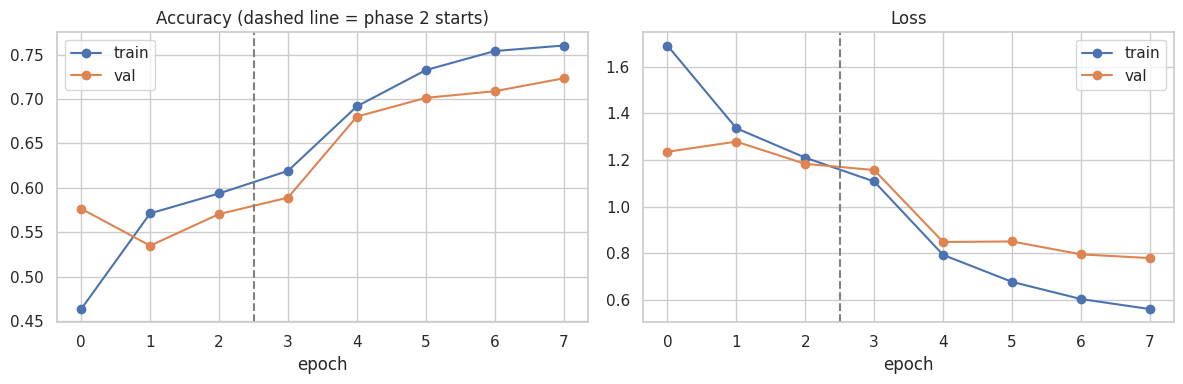

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_acc"], marker="o", label="train")
axes[0].plot(history["val_acc"], marker="o", label="val")
axes[0].axvline(2.5, ls="--", c="gray")
axes[0].set_title("Accuracy (dashed line = phase 2 starts)")
axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history["train_loss"], marker="o", label="train")
axes[1].plot(history["val_loss"], marker="o", label="val")
axes[1].axvline(2.5, ls="--", c="gray")
axes[1].set_title("Loss"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

## 10. Honest evaluation — per-class report & confusion matrix

Accuracy alone is misleading on imbalanced data (EDA §4), so we report:

- **Per-class precision/recall/F1.** The number to highlight on camera is
  **melanoma recall**: of all true melanomas, how many did we catch? For a
  screening tool, a missed melanoma (false negative) is far worse than a
  false alarm.
- **Row-normalized confusion matrix**: each row shows where a true class's
  images went. Look at the `mel` row — the share landing in the `nv` column
  is exactly the mel/nv confusion our EDA predicted (§8). *"Our EDA predicted
  this weakness, and here it is"* is a great video moment.
- Expect weaker numbers on `df` and `vasc` (only ~100–140 images each) —
  say so honestly; acknowledging limitations scores points.

              precision    recall  f1-score   support

       akiec      0.380     0.565     0.455        62
         bcc      0.467     0.770     0.581       100
         bkl      0.565     0.656     0.607       218
          df      0.474     0.643     0.545        28
         mel      0.380     0.569     0.456       218
          nv      0.953     0.763     0.848      1337
        vasc      0.510     0.812     0.627        32

    accuracy                          0.723      1995
   macro avg      0.533     0.683     0.588      1995
weighted avg      0.792     0.723     0.745      1995



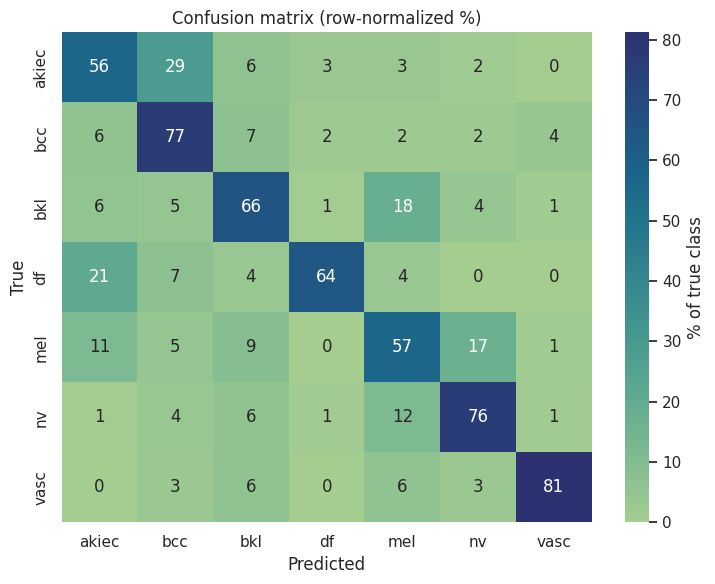

In [10]:
_, _, preds, ys = run_epoch(model, val_loader)
print(classification_report(ys, preds, target_names=CLASSES, digits=3))

cm = confusion_matrix(ys, preds, normalize="true") * 100
plt.figure(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="crest",
            xticklabels=CLASSES, yticklabels=CLASSES,
            cbar_kws={"label": "% of true class"})
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion matrix (row-normalized %)")
plt.tight_layout(); plt.show()

## 11. Save the model for the Streamlit demo

We save only the **state_dict** (the learned weights, ~45 MB), not the whole
object — the standard, portable PyTorch practice. The Streamlit app rebuilds
the same architecture and loads these weights into it.

The `files.download` line pops a browser download. Put the file next to
`app.py` on your laptop and run `streamlit run app.py`.

In [11]:
torch.save(model.state_dict(), "skin_lesion_resnet18.pt")
print("Saved: skin_lesion_resnet18.pt")

from google.colab import files
files.download("skin_lesion_resnet18.pt")

Saved: skin_lesion_resnet18.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Recap — the story you tell in the video

1. **EDA told us** the data is imbalanced, contains duplicate lesions, and
   that mel/nv would be the hard pair.
2. **So we designed**: lesion-level split, pretrained ResNet-18 with our own
   Dropout-regularised head, class-weighted loss, mild augmentation.
3. **We trained in two phases** to protect the pretrained weights, keeping
   the best epoch.
4. **We evaluated honestly**: per-class recall and a confusion matrix that
   confirmed the predicted mel/nv confusion — and we can explain why.
5. **Next:** the Streamlit app with Grad-CAM shows *where* the model looks.

Every choice traces back to something the data showed us. That is the
difference between a project and a tutorial.